# heatmap - Part 4/4\n\n自动拆分版本（按步骤执行）。\n包含统一 bootstrap 和共享模块导入。\n

In [ ]:
# AUTO_BOOTSTRAP_V2
from pathlib import Path
import sys
import os
import builtins
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "projects").exists():
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "projects").exists():
            ROOT = p
            break

NB_PATH = Path.cwd()
if "clone_motif" in str(NB_PATH):
    PROJECT_DIR = ROOT / "projects" / "clone_motif"
else:
    PROJECT_DIR = ROOT / "projects" / "our_multiregion_motif"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUT_FIG = PROJECT_DIR / "outputs" / "figures"
OUT_TABLE = PROJECT_DIR / "outputs" / "tables"
OUT_ARCH = PROJECT_DIR / "outputs" / "archives"

for d in [DATA_PROCESSED, OUT_FIG, OUT_TABLE, OUT_ARCH]:
    d.mkdir(parents=True, exist_ok=True)

SHARED_SRC = ROOT / "projects" / "shared" / "src"
if str(SHARED_SRC) not in sys.path:
    sys.path.append(str(SHARED_SRC))

from motif_common import combination, indices_for_region, union_indices_for_regions, p_to_star, format_p_decimal_3sig, sort_by_order, truncate_colormap

READ_EXT = {".csv", ".json", ".npy", ".pkl", ".xlsx"}
FIG_EXT = {".svg", ".png", ".pdf"}
TABLE_EXT = {".csv", ".xlsx"}


def _as_path(x):
    return Path(x) if isinstance(x, (str, os.PathLike)) else x


def resolve_read_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute() or p.exists():
        return str(p)
    if p.suffix.lower() in READ_EXT:
        for c in [DATA_RAW / p.name, ROOT / p.name]:
            if c.exists():
                return str(c)
    return str(p)


def resolve_write_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute():
        p.parent.mkdir(parents=True, exist_ok=True)
        return str(p)
    ext = p.suffix.lower()
    if ext in FIG_EXT:
        out = OUT_FIG / p.name
    elif ext in TABLE_EXT:
        out = OUT_TABLE / p.name
    elif ext == ".zip":
        out = OUT_ARCH / p.name
    elif ext == ".npy":
        out = DATA_PROCESSED / p.name
    else:
        out = PROJECT_DIR / p
    out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

if not hasattr(builtins, "_orig_open_codex"):
    builtins._orig_open_codex = builtins.open


def _open_patch(file, mode="r", *args, **kwargs):
    if isinstance(file, (str, os.PathLike)):
        if any(m in mode for m in ["r", "a"]):
            file = resolve_read_path(file)
        if any(m in mode for m in ["w", "a", "x"]):
            file = resolve_write_path(file)
    return builtins._orig_open_codex(file, mode, *args, **kwargs)


builtins.open = _open_patch

if not hasattr(np, "_orig_load_codex"):
    np._orig_load_codex = np.load
np.load = lambda file, *a, **k: np._orig_load_codex(resolve_read_path(file), *a, **k)

if not hasattr(np, "_orig_save_codex"):
    np._orig_save_codex = np.save
np.save = lambda file, arr, *a, **k: np._orig_save_codex(resolve_write_path(file), arr, *a, **k)

if not hasattr(pd, "_orig_read_csv_codex"):
    pd._orig_read_csv_codex = pd.read_csv
pd.read_csv = lambda f, *a, **k: pd._orig_read_csv_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd, "_orig_read_excel_codex"):
    pd._orig_read_excel_codex = pd.read_excel
pd.read_excel = lambda f, *a, **k: pd._orig_read_excel_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd.DataFrame, "_orig_to_csv_codex"):
    pd.DataFrame._orig_to_csv_codex = pd.DataFrame.to_csv


def _to_csv_patch(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike)):
        path_or_buf = resolve_write_path(path_or_buf)
    return pd.DataFrame._orig_to_csv_codex(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_patch

if not hasattr(pd.DataFrame, "_orig_to_excel_codex"):
    pd.DataFrame._orig_to_excel_codex = pd.DataFrame.to_excel


def _to_excel_patch(self, excel_writer, *args, **kwargs):
    if isinstance(excel_writer, (str, os.PathLike)):
        excel_writer = resolve_write_path(excel_writer)
    return pd.DataFrame._orig_to_excel_codex(self, excel_writer, *args, **kwargs)


pd.DataFrame.to_excel = _to_excel_patch

try:
    import matplotlib.pyplot as plt
    if not hasattr(plt, "_orig_savefig_codex"):
        plt._orig_savefig_codex = plt.savefig
    plt.savefig = lambda f, *a, **k: plt._orig_savefig_codex(resolve_write_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)
except Exception:
    pass

print(f"[bootstrap] project={PROJECT_DIR.name} data={DATA_RAW}")


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ===== 0. 读数据（5 µm, thr="0"）=====
pkl_path = "wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl"
with open(pkl_path, "rb") as f:
    results_all = pickle.load(f)["results"]

param_use = 5
thr_use   = "0"
res5      = results_all[param_use]   # dict: region -> info

# ==================== 1. 在这里重新生成 names 和 labels ====================

# 你给的 4 个 cluster 顺序
cluster1_names = [
    "FRP",
    "PL",
    "ILA",
    "AId",
    "AIv",
    "ACAd",
    "ACAv",
    "ORBl",
    "ORBvl",
    "ORBm",
    "MOs",
]

cluster2_names = [
    "POST",
    "PRE",
    "ProS",
    "SUB",
    "CA3",
    "PAR",
    "CA1",
    "DG",
]

cluster3_names = [
    "MOp",
    "SSs",
    "SSp-bfd",
    "SSp-m",
    "SSp-n",
    "SSp-ul",
    "RSPd",
    "RSPv",
    "RSPagl",
    "TEa",
    "ENT",
    "VISp",
    "VISa",
    "VISl",
    "VISli",
]

cluster4_names = [
    "VISam",
    "VISpm",
    "VISrl",
    "VISpl",
    "VISpor",
    "VISal",
    "SSp-ll",
    "SSp-tr",
    "AUDp",
    "AUDv",
    "AUDd",
    "AUDpo",
    "PIR",
    "VISC",
    "GU",
    "AIp",
]

# 所有在 pkl 里的 region 名字（过滤掉一些无效区域，按你之前的习惯）
all_regions = sorted(res5.keys())
exclude_regions = {"SSp", "VPL", "PERI", "ECT", "PO", "PR"}  # 你之前过滤的那几个
all_regions = [r for r in all_regions if r not in exclude_regions]

# 按你给的顺序拼起来
custom_order = (
    cluster1_names +
    cluster2_names +
    cluster3_names +
    cluster4_names
)

# 先按自定义顺序挑出“在数据里的”
ordered_names_list = [r for r in custom_order if r in all_regions]

# 如果 pkl 里还有别的区域，但你没在 4 个 cluster 里列出来，就附加在最后（cluster=0）
extra_regions = [r for r in all_regions if r not in ordered_names_list]
if extra_regions:
    print("[WARN] 这些区域在 pkl 里有，但没在 4 个 cluster 里列出，将作为 C0 附加在最后：")
    print(extra_regions)
    ordered_names_list += extra_regions

# 最终用的 names（这个顺序后面你还可以复用）
names = np.array(ordered_names_list, dtype=object)

# 构造 name -> cluster 映射
name_to_cluster = {}
for r in cluster1_names:
    name_to_cluster[r] = 1
for r in cluster2_names:
    name_to_cluster[r] = 2
for r in cluster3_names:
    name_to_cluster[r] = 3
for r in cluster4_names:
    name_to_cluster[r] = 4
for r in extra_regions:
    name_to_cluster[r] = 0  # 没在 4 个列表里的，标成 0 类

labels = np.array([name_to_cluster.get(r, 0) for r in names], dtype=int)

print("最终区域顺序 names =", names)
print("对应 cluster labels =", labels)

# ==================== 2. 一张图画所有 region 的 motif 柱状图 ====================

motif_labels = [f"M{i}" for i in range(1, 14)]
x = np.arange(13)

bar_w   = 0.18
col_real = "#0072B2"  # 蓝
col_mu   = "#E69F00"  # 橙
col_diff = "#009E73"  # 绿

n_reg = len(names)
fig, axes = plt.subplots(
    n_reg, 1,
    figsize=(7, 2.3 * n_reg),
    sharex=True
)

if n_reg == 1:
    axes = [axes]

for idx, ax in enumerate(axes):
    region = names[idx]
    c      = labels[idx]   # cluster 编号

    mr = res5[region]["motif_results"][thr_use]

    real = np.asarray(mr["real_motif"], float)
    mu   = np.asarray(mr["er_mu_eq"],   float)

    # 有些结果可能是长度 14（第 0 个占位），这里切掉第 0 元素
    if real.shape[0] == 14:
        real = real[1:]
    if mu.shape[0] == 14:
        mu = mu[1:]
    if real.shape[0] != 13 or mu.shape[0] != 13:
        ax.set_visible(False)
        continue

    # log2 变换（只对 >0 的做）
    log_real = np.full_like(real, np.nan, dtype=float)
    log_mu   = np.full_like(mu,   np.nan, dtype=float)

    mask_r = real > 0
    mask_m = mu   > 0
    log_real[mask_r] = np.log2(real[mask_r])
    log_mu[mask_m]   = np.log2(mu[mask_m])
    log_diff = log_real - log_mu

    # 三组柱子：real, mu, diff
    ax.bar(x - bar_w, log_real, width=bar_w,
           color=col_real, alpha=0.9,
           label="log2(real)" if idx == 0 else None)
    ax.bar(x,         log_mu,   width=bar_w,
           color=col_mu,   alpha=0.9,
           label="log2(er_mu_eq)" if idx == 0 else None)
    ax.bar(x + bar_w, log_diff, width=bar_w,
           color=col_diff, alpha=0.9,
           label="log2(real) - log2(mu_eq)" if idx == 0 else None)

    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylabel("log2 / diff", fontsize=7)

    # 标题里带上 cluster 编号
    if c == 0:
        ax.set_title(f"{region} (C0)", loc="left", fontsize=8.5)
    else:
        ax.set_title(f"{region} (C{int(c)})", loc="left", fontsize=8.5)

    # 只在最后一行画 x 轴刻度
    if idx == n_reg - 1:
        ax.set_xticks(x)
        ax.set_xticklabels(motif_labels, rotation=45, ha="right", fontsize=8)
    else:
        ax.set_xticks([])
        ax.set_xticklabels([])

# 统一图例放在第一行
axes[0].legend(loc="upper right", fontsize=7)

fig.suptitle(
    f"All regions – log2(real), log2(er_mu_eq) and difference\n(5 µm, thr={thr_use})",
    fontsize=12, y=0.995
)

plt.tight_layout()

# 存成一张 SVG，透明底
fig.savefig(
    "cluster_motif_bar_all_regions.svg",
    bbox_inches='tight',
    dpi=300,
    transparent=True
)

plt.close(fig)

最终区域顺序 names = ['FRP' 'PL' 'ILA' 'AId' 'AIv' 'ACAd' 'ACAv' 'ORBl' 'ORBvl' 'ORBm' 'MOs'
 'POST' 'PRE' 'ProS' 'SUB' 'CA3' 'PAR' 'CA1' 'DG' 'RSPd' 'RSPv' 'RSPagl'
 'TEa' 'ENT' 'SSs' 'MOp' 'SSp-bfd' 'SSp-m' 'SSp-n' 'SSp-ul' 'VISp' 'VISa'
 'VISl' 'VISli' 'VISam' 'VISpm' 'VISrl' 'VISpl' 'VISpor' 'VISal' 'SSp-ll'
 'SSp-tr' 'AUDp' 'AUDv' 'AUDd' 'AUDpo' 'PIR' 'VISC' 'GU' 'AIp']
对应 cluster labels = [1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4]


FRP: 原节点 222, 用 100, 剩节点 83, 原边 343, 剩边 240 (砍掉最弱 30%)


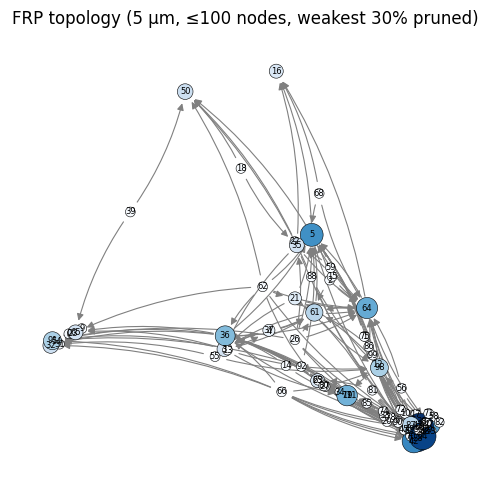

MOp: 原节点 957, 用 100, 剩节点 94, 原边 489, 剩边 342 (砍掉最弱 30%)


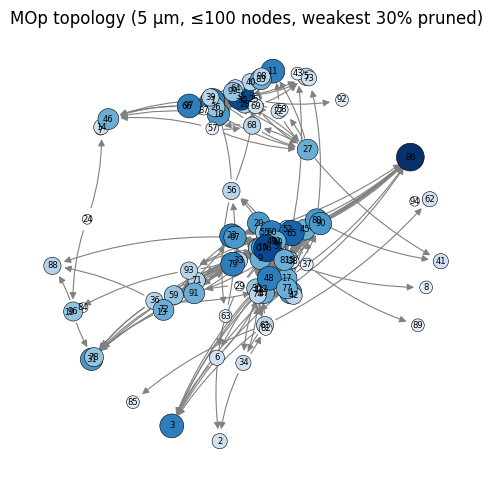

In [13]:
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ========== 1. 读 pkl，拿 5 µm 下的 FRP / MOp ==========

pkl_path = "wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl"

with open(pkl_path, "rb") as f:
    results_all = pickle.load(f)["results"]   # dict[param] -> {region -> info}

param_use = 5
res_5um   = results_all[param_use]

A_frp_full = np.asarray(res_5um["FRP"]["sc"], dtype=float)
A_mop_full = np.asarray(res_5um["MOp"]["sc"], dtype=float)


# ========== 2. 子采样 + 去掉最弱若干百分比的边 + 去孤立点 + 画图 ==========

def sample_and_plot_topology(A_full, region_name, n_sample=100, drop_frac=0.1, seed=0):
    """
    A_full: 原始 n x n 加权有向邻接矩阵
    n_sample: 最多保留多少个节点
    drop_frac: 去掉的弱边比例（0.1 = 最弱 10%）
    """
    n_full = A_full.shape[0]
    n_use  = min(n_full, n_sample)

    # ----- 随机子采样节点 -----
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_full, size=n_use, replace=False)
    A   = A_full[np.ix_(idx, idx)]

    # ----- 找非零边，砍掉最弱 drop_frac -----
    src, tgt = np.where(A > 0)
    if src.size == 0:
        print(f"{region_name}: 没有边，画不了。")
        return

    w = A[src, tgt]
    q = np.quantile(w, drop_frac)       # 比如 0.3 → 最弱 30%
    keep = w >= q

    src_keep = src[keep]
    tgt_keep = tgt[keep]

    # ----- 构图 -----
    G = nx.DiGraph()
    G.add_nodes_from(range(n_use))                 # 子采样后的节点编号 0..n_use-1
    G.add_edges_from(zip(src_keep, tgt_keep))

    # 去掉孤立节点
    isolates = [n for n, deg in G.degree() if deg == 0]
    G.remove_nodes_from(isolates)

    print(
        f"{region_name}: 原节点 {n_full}, 用 {n_use}, 剩节点 {G.number_of_nodes()}, "
        f"原边 {len(w)}, 剩边 {G.number_of_edges()} (砍掉最弱 {int(drop_frac*100)}%)"
    )

    if G.number_of_nodes() == 0:
        print(f"{region_name}: 全成孤立点了，图为空。")
        return

    # ======= spring 布局（稍微分散一点）=======
    n_nodes = G.number_of_nodes()
    k = 2.0 / np.sqrt(n_nodes)
    pos = nx.spring_layout(
        G,
        seed=seed,
        k=k,
        iterations=300,
        scale=2.0,
    )

    # ======= 入度控制点大小 & 颜色 =======
    indeg = np.array([d for _, d in G.in_degree()])
    d_min, d_max = indeg.min(), indeg.max()

    # 大小映射到 50–400
    if d_max == d_min:
        node_sizes = np.full_like(indeg, 150, dtype=float)
    else:
        node_sizes = 50 + (indeg - d_min) / (d_max - d_min) * 350

    # 颜色映射到 Blues：入度越大越深
    cmap = plt.cm.Blues
    if d_max == d_min:
        norm_deg = np.ones_like(indeg, dtype=float)
    else:
        norm_deg = (indeg - d_min) / (d_max - d_min)
    node_colors = [cmap(x) for x in norm_deg]

    # ----- 画图 -----
    plt.figure(figsize=(5, 5))
    ax = plt.gca()
    ax.set_axis_off()

    nx.draw_networkx_edges(
        G, pos,
        arrowstyle='-|>',
        arrowsize=10,
        edge_color="0.5",
        width=0.8,
        connectionstyle="arc3,rad=0.1",
    )

    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,    # ✅ 颜色体现入度
        node_size=node_sizes,      # ✅ 大小也体现入度
        edgecolors="black",
        linewidths=0.4,
    )

    labels = {nid: str(nid) for nid in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=6)

    plt.title(
        f"{region_name} topology (5 µm, ≤{n_sample} nodes, "
        f"weakest {int(drop_frac*100)}% pruned)"
    )
    plt.tight_layout()
    plt.show()


# ========== 3. 画 FRP 和 MOp（各最多 100 个节点） ==========

sample_and_plot_topology(A_frp_full, "FRP", n_sample=100, drop_frac=0.3, seed=0)
sample_and_plot_topology(A_mop_full, "MOp", n_sample=100, drop_frac=0.3, seed=1)

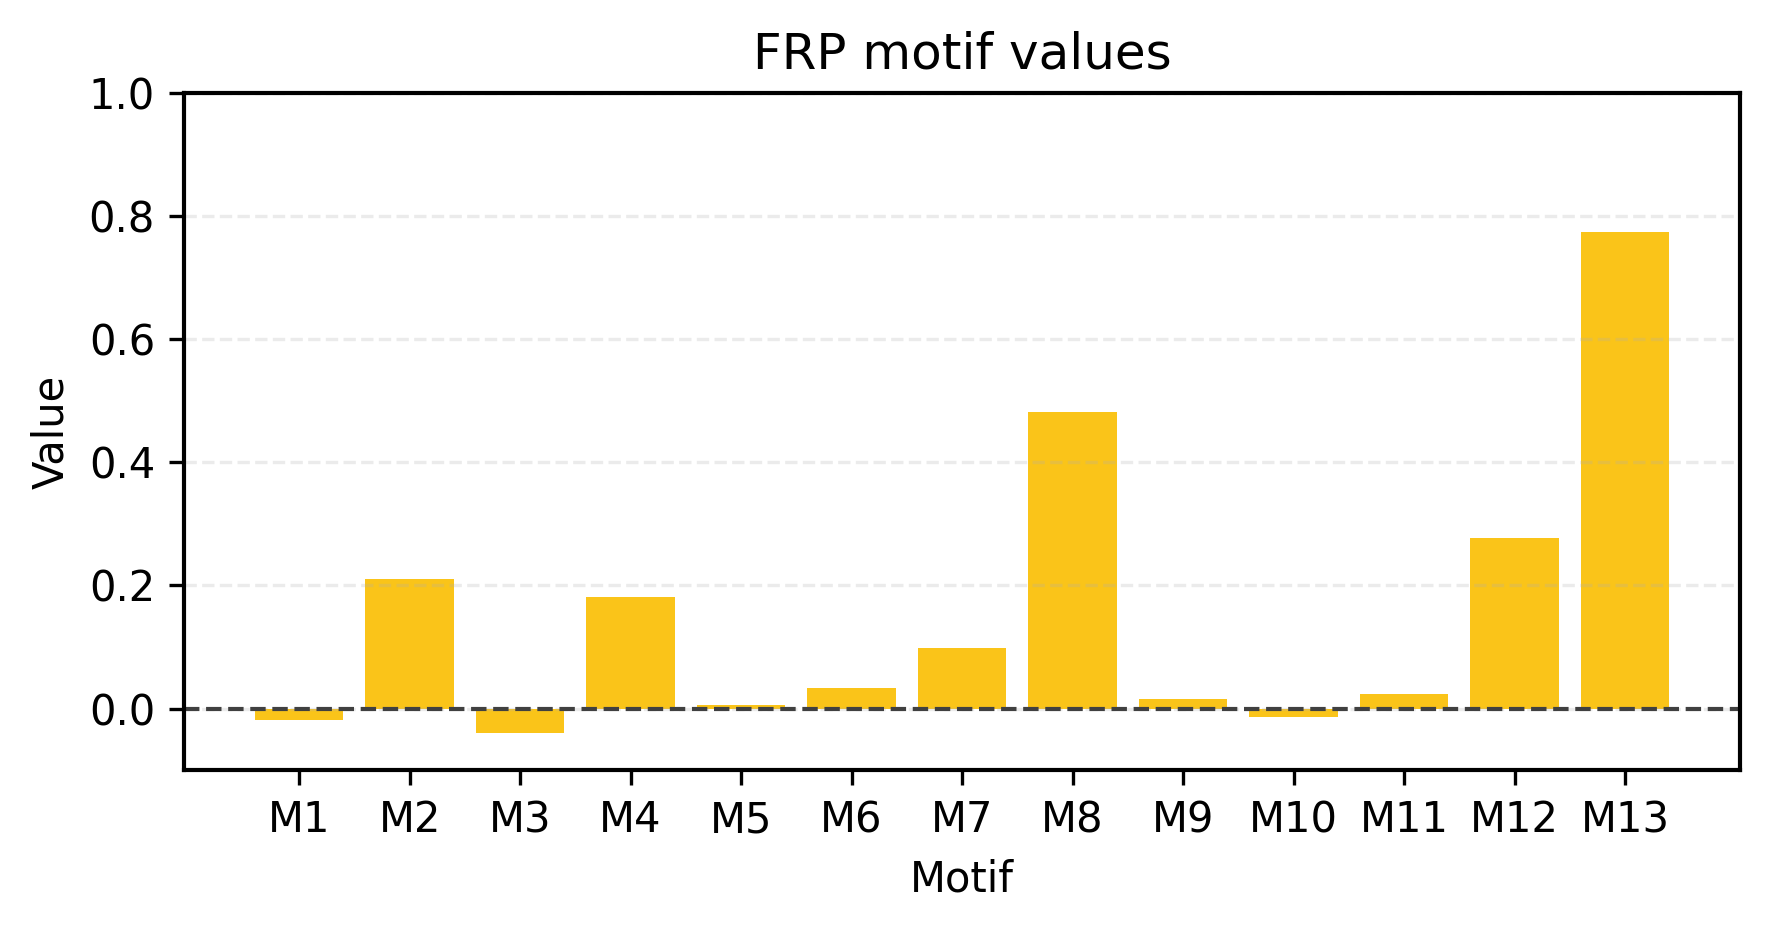

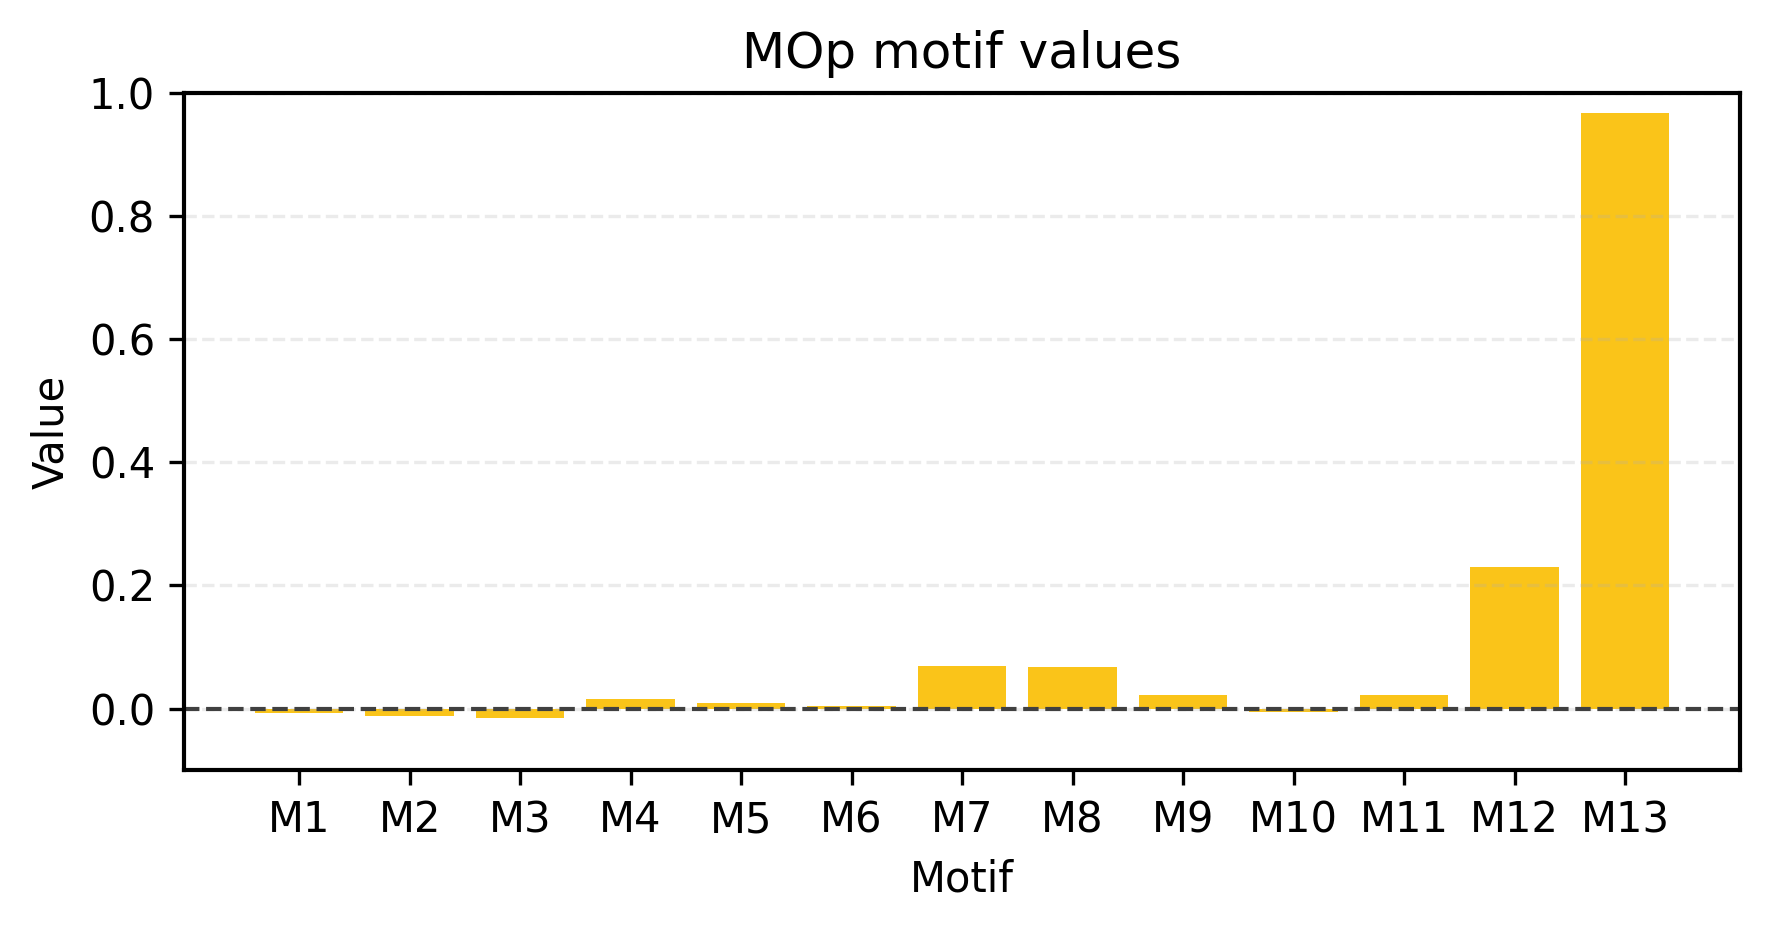

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ===== 全局论文风格 =====
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 10,
    "axes.linewidth": 1.0,
})

# ===== 数据 =====
MOp = np.array([
    -0.00722737, -0.01273873, -0.01561858,  0.01562969,  0.00866638,
     0.00402705,  0.06961442,  0.06682548,  0.02137642, -0.00520205,
     0.02198735,  0.23077471,  0.96730022
], dtype=float)

FRP = np.array([
    -0.01928962,  0.20980253, -0.03922592,  0.1819576 ,  0.00601686,
     0.03389555,  0.09883095,  0.48222753,  0.01604604, -0.01396816,
     0.02385361,  0.2778669 ,  0.77410329
], dtype=float)

motif_ids = np.arange(1, 14)
x = np.arange(len(motif_ids))
xticklabels = [f"M{i}" for i in motif_ids]

# ===== 一个统一颜色（你要换就改这里）=====
COL_BAR = "#fabe00"  # 单一颜色

# ===== 统一 y 轴范围 =====
YMIN, YMAX = -0.1, 1.0

# =========================
# 图1：FRP 单独柱状图
# =========================
fig1, ax1 = plt.subplots(figsize=(6.0, 3.2))
ax1.bar(x, FRP, color=COL_BAR, alpha=0.9, linewidth=0)

ax1.set_ylim(YMIN, YMAX)
ax1.axhline(0, color="0.25", lw=1.0, linestyle="--")
ax1.set_xticks(x)
ax1.set_xticklabels(xticklabels)
ax1.set_xlabel("Motif")
ax1.set_ylabel("Value")
ax1.set_title("FRP motif values")
ax1.grid(axis="y", linestyle="--", alpha=0.25)

fig1.tight_layout()
fig1.savefig("FRP_motif_bars_singlecolor.svg", format="svg",
             bbox_inches="tight", transparent=True)
plt.show()

# =========================
# 图2：MOp 单独柱状图
# =========================
fig2, ax2 = plt.subplots(figsize=(6.0, 3.2))
ax2.bar(x, MOp, color=COL_BAR, alpha=0.9, linewidth=0)

ax2.set_ylim(YMIN, YMAX)
ax2.axhline(0, color="0.25", lw=1.0, linestyle="--")
ax2.set_xticks(x)
ax2.set_xticklabels(xticklabels)
ax2.set_xlabel("Motif")
ax2.set_ylabel("Value")
ax2.set_title("MOp motif values")
ax2.grid(axis="y", linestyle="--", alpha=0.25)

fig2.tight_layout()
fig2.savefig("MOp_motif_bars_singlecolor.svg", format="svg",
             bbox_inches="tight", transparent=True)
plt.show()